In [36]:
%pip install pandas matplotlib seaborn

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
co2 = pd.read_csv("/Users/danisanchez/Downloads/ManuaLoa_CO2 (1).csv")
aqs = pd.read_csv("/Users/danisanchez/Downloads/LA_AQS_2023.csv")

In [4]:
display(co2.head())
print(co2.columns.tolist())
co2.info()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.70,314.43,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.71,-1,-9.99,-0.99
3,1958,6,1958.4548,317.24,315.14,-1,-9.99,-0.99
4,1958,7,1958.5370,315.86,315.18,-1,-9.99,-0.99


['year', 'month', 'decimal date', 'average', 'deseasonalized', 'ndays', 'sdev', 'unc']
<class 'pandas.DataFrame'>
RangeIndex: 791 entries, 0 to 790
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            791 non-null    int64  
 1   month           791 non-null    int64  
 2   decimal date    791 non-null    float64
 3   average         791 non-null    float64
 4   deseasonalized  791 non-null    float64
 5   ndays           791 non-null    int64  
 6   sdev            791 non-null    float64
 7   unc             791 non-null    float64
dtypes: float64(5), int64(3)
memory usage: 49.6 KB


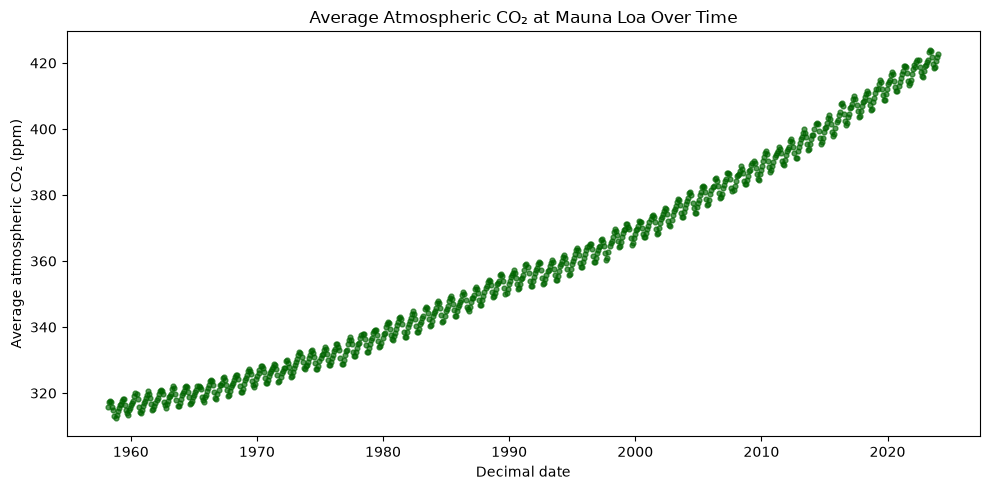

In [5]:
co2.plot.scatter(
    x="decimal date",
    y="average",
    figsize=(10, 5),
    color="darkgreen",
    s=12,
    alpha=0.65
)

plt.xlabel("Decimal date")
plt.ylabel("Average atmospheric CO₂ (ppm)")
plt.title("Average Atmospheric CO₂ at Mauna Loa Over Time")
plt.tight_layout()
plt.show()

In [6]:
print(co2.columns.tolist())
display(co2.head())

['year', 'month', 'decimal date', 'average', 'deseasonalized', 'ndays', 'sdev', 'unc']


,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.70,314.43,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.71,-1,-9.99,-0.99
3,1958,6,1958.4548,317.24,315.14,-1,-9.99,-0.99
4,1958,7,1958.5370,315.86,315.18,-1,-9.99,-0.99


In [8]:
display(aqs.head())
print(aqs.columns.tolist())
print(aqs.shape)

,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,AQI,Daily Criteria Indicator,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source
0,6,37,1103,68103,1,34.06659,-118.22688,WGS84,Ambient Min Temperature,24 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
1,6,37,1103,42602,3,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,16,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
2,6,37,1103,62201,1,34.06659,-118.22688,WGS84,Relative Humidity,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
3,6,37,1103,62101,1,34.06659,-118.22688,WGS84,Outdoor Temperature,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
4,6,37,1103,42603,1,34.06659,-118.22688,WGS84,Oxides of nitrogen (NOx),1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


['State Code', 'County Code', 'Site Number', 'Parameter Code', 'POC', 'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Duration Description', 'Pollutant Standard', 'Date (Local)', 'Year', 'Day In Year (Local)', 'Units of Measure', 'Exceptional Data Type', 'Nonreg Observation Count', 'Observation Count', 'Observation Percent', 'Nonreg Arithmetic Mean', 'Arithmetic Mean', 'Nonreg First Maximum Value', 'First Maximum Value', 'First Maximum Hour', 'AQI', 'Daily Criteria Indicator', 'Tribe Name', 'State Name', 'County Name', 'City Name', 'Local Site Name', 'Address', 'MSA or CBSA Name', 'Data Source']
(22160, 34)


In [11]:
print(aqs["Parameter Name"].unique())

<ArrowStringArray>
[   'Ambient Min Temperature',     'Nitrogen dioxide (NO2)',
          'Relative Humidity',        'Outdoor Temperature',
   'Oxides of nitrogen (NOx)',    'Wind Direction - Scalar',
   'Sample Min Baro Pressure', 'Wind Direction - Resultant',
   'Sample Max Baro Pressure',        'Elapsed Sample Time',
 ...
             'Iron (TSP) STP',        'Strontium (TSP) STP',
               'Acetaldehyde',               'Formaldehyde',
        'Methyl ethyl ketone',       'Molybdenum (TSP) STP',
        'Beryllium (TSP) STP',            'Propionaldehyde',
              'Butyraldehyde',              'Hexanaldehyde']
Length: 164, dtype: str


In [14]:
aqs.loc[
    aqs["Parameter Name"].str.contains("ozone|O3", case=False, na=False),
    "Parameter Name"
].unique()

<ArrowStringArray>
['Ozone']
Length: 1, dtype: str

In [15]:
o3 = aqs[
    aqs["Parameter Name"].str.contains("ozone|O3", case=False, na=False)
].copy()

no2 = aqs[
    aqs["Parameter Name"] == "Nitrogen dioxide (NO2)"
].copy()

print("O3 rows:", len(o3))
print("NO2 rows:", len(no2))

O3 rows: 546
NO2 rows: 1092


In [16]:
print(aqs.columns.tolist())

['State Code', 'County Code', 'Site Number', 'Parameter Code', 'POC', 'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Duration Description', 'Pollutant Standard', 'Date (Local)', 'Year', 'Day In Year (Local)', 'Units of Measure', 'Exceptional Data Type', 'Nonreg Observation Count', 'Observation Count', 'Observation Percent', 'Nonreg Arithmetic Mean', 'Arithmetic Mean', 'Nonreg First Maximum Value', 'First Maximum Value', 'First Maximum Hour', 'AQI', 'Daily Criteria Indicator', 'Tribe Name', 'State Name', 'County Name', 'City Name', 'Local Site Name', 'Address', 'MSA or CBSA Name', 'Data Source']


In [17]:
for column in aqs.columns:
    if any(word in column.lower() for word in [
        "date", "value", "sample", "mean", "unit"
    ]):
        print(column)

Date (Local)
Units of Measure
Nonreg Arithmetic Mean
Arithmetic Mean
Nonreg First Maximum Value
First Maximum Value


In [18]:
display(o3.head())
display(no2.head())

,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,AQI,Daily Criteria Indicator,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source
20,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
21,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,8-HR RUN AVG BEGIN HOUR,...,32,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
64,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
65,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,8-HR RUN AVG BEGIN HOUR,...,25,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
204,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,AQI,Daily Criteria Indicator,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source
1,6,37,1103,42602,3,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,16,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
19,6,37,1103,42602,1,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,17,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
29,6,37,1103,42602,1,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,17,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
41,6,37,1103,42602,3,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,16,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
44,6,37,1103,42602,3,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,20,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


In [19]:
print(aqs.columns.tolist())

['State Code', 'County Code', 'Site Number', 'Parameter Code', 'POC', 'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Duration Description', 'Pollutant Standard', 'Date (Local)', 'Year', 'Day In Year (Local)', 'Units of Measure', 'Exceptional Data Type', 'Nonreg Observation Count', 'Observation Count', 'Observation Percent', 'Nonreg Arithmetic Mean', 'Arithmetic Mean', 'Nonreg First Maximum Value', 'First Maximum Value', 'First Maximum Hour', 'AQI', 'Daily Criteria Indicator', 'Tribe Name', 'State Name', 'County Name', 'City Name', 'Local Site Name', 'Address', 'MSA or CBSA Name', 'Data Source']


In [20]:
o3 = aqs[
    aqs["Parameter Name"].str.contains("Ozone", case=False, na=False)
].copy()

no2 = aqs[
    aqs["Parameter Name"] == "Nitrogen dioxide (NO2)"
].copy()

print("O3 rows:", len(o3))
print("NO2 rows:", len(no2))

print("O3 units:", o3["Units of Measure"].unique())
print("NO2 units:", no2["Units of Measure"].unique())

O3 rows: 546
NO2 rows: 1092
O3 units: <ArrowStringArray>
['Parts per million']
Length: 1, dtype: str
NO2 units: <ArrowStringArray>
['Parts per billion']
Length: 1, dtype: str


In [21]:
o3["date"] = pd.to_datetime(o3["Date (Local)"], errors="coerce")
no2["date"] = pd.to_datetime(no2["Date (Local)"], errors="coerce")

o3["O3"] = pd.to_numeric(o3["Arithmetic Mean"], errors="coerce")
no2["NO2"] = pd.to_numeric(no2["Arithmetic Mean"], errors="coerce")

o3 = o3.dropna(subset=["date", "O3"])
no2 = no2.dropna(subset=["date", "NO2"])

In [24]:
if o3["Units of Measure"].str.contains(
    "parts per million", case=False, na=False
).any():
    o3["O3_ppb"] = o3["O3"] * 1000
else:
    o3["O3_ppb"] = o3["O3"]


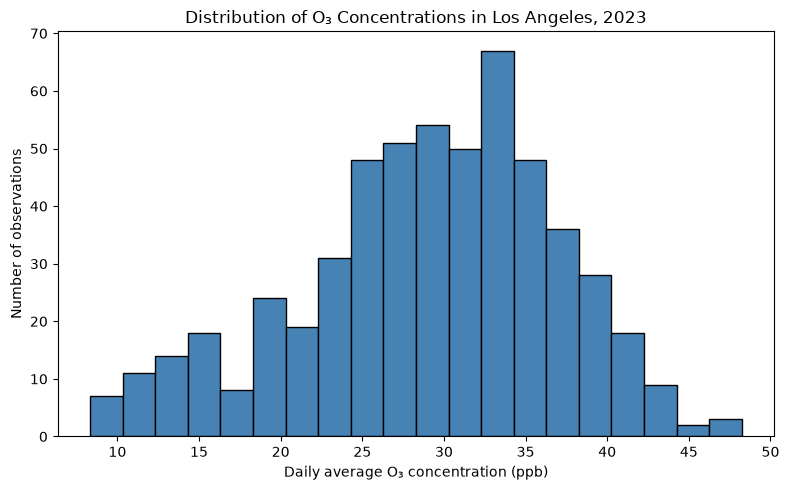

In [25]:
plt.figure(figsize=(8, 5))

plt.hist(
    o3["O3_ppb"],
    bins=20,
    color="steelblue",
    edgecolor="black"
)

plt.xlabel("Daily average O₃ concentration (ppb)")
plt.ylabel("Number of observations")
plt.title("Distribution of O₃ Concentrations in Los Angeles, 2023")
plt.tight_layout()

plt.savefig("o3_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
print(no2["Units of Measure"].value_counts())

Units of Measure
Parts per billion    1092
Name: count, dtype: int64


In [28]:
no2["NO2_ppb"] = no2["NO2"] * 1000

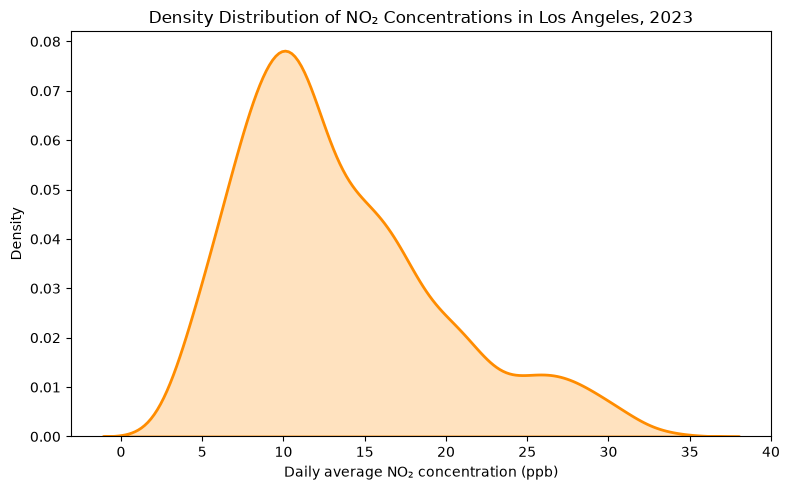

In [37]:
plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=no2,
    x="NO2",
    fill=True,
    color="darkorange",
    linewidth=2
)

plt.xlabel("Daily average NO₂ concentration (ppb)")
plt.ylabel("Density")
plt.title("Density Distribution of NO₂ Concentrations in Los Angeles, 2023")
plt.tight_layout()

plt.savefig("no2_density.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
o3_daily = (
    o3.groupby("date", as_index=False)["O3_ppb"]
    .mean()
)

no2_daily = (
    no2.groupby("date", as_index=False)["NO2_ppb"]
    .mean()
)

In [31]:
air_daily = o3_daily.merge(
    no2_daily,
    on="date",
    how="inner"
)

display(air_daily.head())
print("Number of matching dates:", len(air_daily))

,date,O3_ppb,NO2_ppb
0,2023-01-01,30.0600,4683.3335
1,2023-01-02,17.5725,15068.7500
2,2023-01-03,22.1175,11662.5000
3,2023-01-04,24.0440,14363.6365
4,2023-01-05,23.2755,11027.0830


Number of matching dates: 273


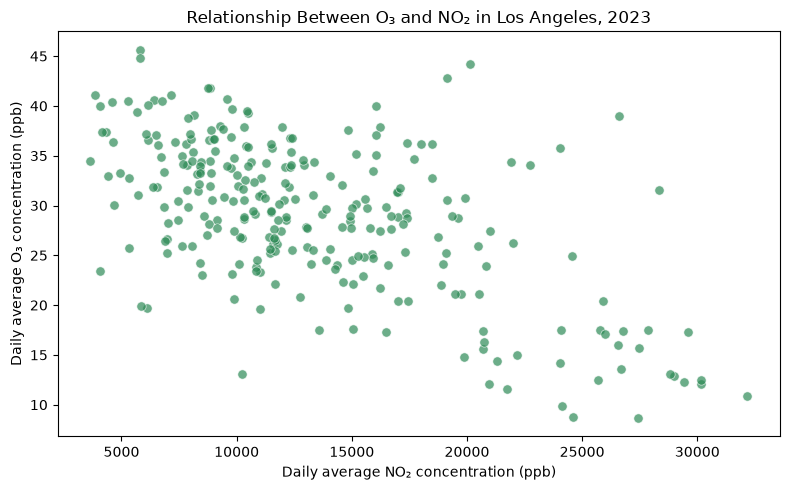

In [32]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=air_daily,
    x="NO2_ppb",
    y="O3_ppb",
    color="seagreen",
    alpha=0.7,
    s=45
)

plt.xlabel("Daily average NO₂ concentration (ppb)")
plt.ylabel("Daily average O₃ concentration (ppb)")
plt.title("Relationship Between O₃ and NO₂ in Los Angeles, 2023")
plt.tight_layout()

plt.savefig("o3_vs_no2.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
air_daily[["O3_ppb", "NO2_ppb"]].corr()

,O3_ppb,NO2_ppb
O3_ppb,1.000000,-0.606239
NO2_ppb,-0.606239,1.000000


In [34]:
high_o3_days = (
    o3[o3["O3_ppb"] > 35][["date"]]
    .drop_duplicates()
)

high_o3_days["month"] = high_o3_days["date"].dt.month

days_per_month = (
    high_o3_days.groupby("month")
    .size()
    .reindex(range(1, 13), fill_value=0)
)

days_per_month

month
1      0
2      5
3     10
4     21
5     15
6      4
7     15
8      4
9     14
10     0
11     0
12     0
dtype: int64

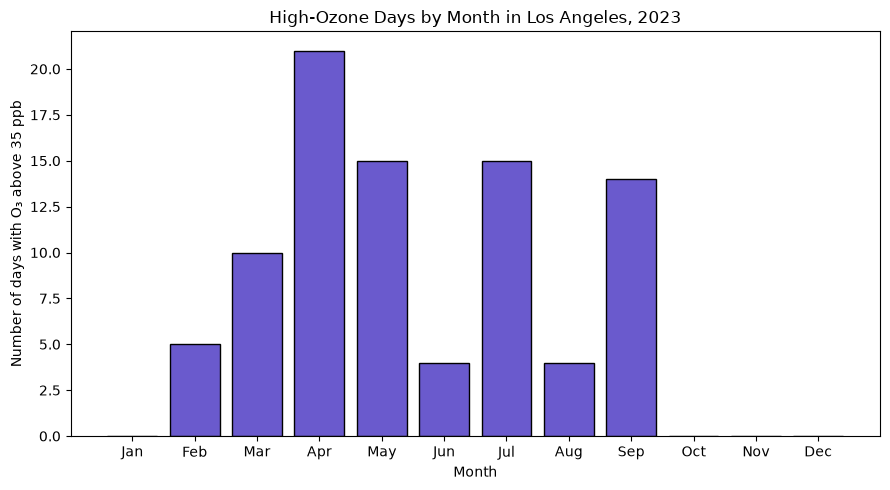

In [35]:
month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(9, 5))

plt.bar(
    month_names,
    days_per_month.values,
    color="slateblue",
    edgecolor="black"
)

plt.xlabel("Month")
plt.ylabel("Number of days with O₃ above 35 ppb")
plt.title("High-Ozone Days by Month in Los Angeles, 2023")
plt.tight_layout()

plt.savefig("high_o3_days.png", dpi=300, bbox_inches="tight")
plt.show()